In [2]:
# !pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.6 MB/s eta 0:00:00


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

In [4]:
from google.colab import userdata

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [7]:
subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=userdata.get('GROQ_API_KEY')
)

In [8]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [9]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [10]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [12]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=userdata.get('GROQ_API_KEY')
)

In [13]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [14]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [15]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

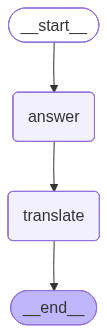

In [16]:
graph = parent_builder.compile()

graph

In [17]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how matter and energy behave at the smallest scales—typically atomic, sub‑atomic, and even smaller (electrons, photons, atoms, nuclei, quarks, etc.).  \n\n---\n\n## Core ideas\n\n| Concept | What it means | Example |\n|---------|---------------|---------|\n| **Quantization** | Certain physical quantities (energy, angular momentum, electric charge) can only take on discrete “chunks” called quanta. | An electron in a hydrogen atom can only occupy specific energy levels; it cannot have an energy in between. |\n| **Wave‑particle duality** | Particles exhibit both wave‑like and particle‑like properties, depending on how they are observed. | Light can interfere like a wave (double‑slit experiment) yet also be detected as individual photons. |\n| **Superposition** | A quantum system can exist in multiple possible states simultane